In [ ]:
#imports
import sys
import os

# Adds the parent directory to the search path
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json



In [21]:
#read in file
df = pd.read_csv('PositronBeam_2p86GeV/Beam_FeasibilityStudy_20260421.dat', sep=r'\s+')
print(list(df.columns))

['x[mm]', 'xp[mrad]', 'y[mm]', 'yp[mrad]', 't[mm/c]', 'p[MeV/c]', 'ID']


In [22]:
#calculating the emittance
def CalcEmittanceManual(df, position, angle):
    pos = df[position].values
    ang = df[angle].values

    x_c= pos-np.mean(pos)
    xp_c= ang-np.mean(ang)

    x2_mean = np.mean(x_c**2)
    xp2_mean = np.mean(xp_c**2)
    xxp_mean = np.mean(x_c * xp_c)
    
    emittance = np.sqrt(x2_mean * xp2_mean - xxp_mean**2)

    return emittance

def CalcEmittanceAuto(df, position, angle):
    pos = df[position].values
    ang = df[angle].values
    cov = np.cov(pos, ang) 
    print(cov)
    emittance=np.sqrt(np.linalg.det(cov))
    return emittance

def NormalisedEmittance(pos,angle,emittance):

    beta = np.cov(pos, angle)[0, 0] / emittance
    gamma = np.cov(pos, angle)[1, 1] / emittance
    
    # 4. Normalize
    n_emittance = beta * gamma * emittance
    return n_emittance


# Twiss parameters
def get_twiss(pos, angle,emittance):
   
    p0_mev = 2860.0
    delta = (df['p[MeV/c]'].values - p0_mev) / p0_mev

    beta = np.cov(pos, angle)[0, 0] / emittance
    gamma = np.cov(pos, angle)[1, 1] / emittance
    alpha = -np.cov(pos, angle)[0, 1] / emittance
    dispersion_x = np.cov(pos, delta)[0, 1] / np.var(delta)
    disp_prime_x = np.cov(angle, delta)[0, 1] / np.var(delta)


    
    return alpha, beta, gamma,dispersion_x,disp_prime_x


def plot_twiss_ellipse(beta, alpha, emittance):
    gamma = (1 + alpha**2) / beta
    
    theta = np.linspace(0, 2*np.pi, 100)
    x_circle = np.cos(theta)
    y_circle = np.sin(theta)
    
    
    x = np.sqrt(emittance * beta) * x_circle
    xp = -(alpha / np.sqrt(beta)) * np.sqrt(emittance) * x_circle + (1 / np.sqrt(beta)) * np.sqrt(emittance) * y_circle
    
    plt.figure(figsize=(6,6))
    plt.plot(x, xp, label=f'α={alpha}, β={beta}')
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.xlabel('Position x [m]')
    plt.ylabel("Divergence x' [rad]")
    plt.title('Phase Space Twiss Ellipse')
    plt.grid(True, linestyle='--')
    plt.legend()
    plt.axis('equal')
    plt.show()



In [23]:

emittance_x=CalcEmittanceAuto(df, 'x[mm]', 'xp[mrad]')
m_emittance_x=CalcEmittanceManual(df, 'x[mm]', 'xp[mrad]')
nemitt_x=NormalisedEmittance(df['x[mm]'],df['xp[mrad]'],emittance_x)
print(nemitt_x)
print(f'Horizontal geometric emittance:{emittance_x*1e3} nm, {m_emittance_x*1e3}nm' )

emittance_y=CalcEmittanceAuto(df, 'y[mm]', 'yp[mrad]')
m_emittance_y=CalcEmittanceManual(df, 'y[mm]', 'yp[mrad]')
print(f'Vertical geometric emittance:{emittance_y*1e3} nm, {m_emittance_y*1e3}nm' )
nemitt_y=NormalisedEmittance(df['x[mm]'],df['xp[mrad]'],emittance_y)
print(nemitt_y)

ax,bx,gx, dx,ddx=get_twiss(df['x[mm]'], df['xp[mrad]'],emittance_x)
ay,by,gy,dy,ddy=get_twiss(df['x[mm]'], df['xp[mrad]'],emittance_y)
print(f"Beam Twiss: alpha_x={ax:.3f}, beta_x={bx:.3f} m, dx={dx:.3f} m,ddx={ddx:.3f} m")
print(f"Beam Twiss: alpha_y={ay:.3f}, beta_y={by:.3f} m, dy={dx:.3f} m,ddy={ddx:.3f} m")

p_array=df['p[MeV/c]']

p_avg = np.mean(p_array)
rms_spread = np.std(p_array)  
relative_spread = (rms_spread / p_avg) *100

print(f"RMS Momentum Spread: {relative_spread} %")


[[45.89149056  6.85166378]
 [ 6.85166378  1.18622446]]
19.888000019031033
Horizontal geometric emittance:2737.2087910544365 nm, 2737.1283771530125nm
[[ 8.45459262 -1.11326453]
 [-1.11326453  0.93753738]]
Vertical geometric emittance:2585.950249047885 nm, 2585.874278829926nm
21.05129768394647
Beam Twiss: alpha_x=-2.503, beta_x=16.766 m, dx=0.150 m,ddx=0.253 m
Beam Twiss: alpha_y=-2.650, beta_y=17.746 m, dy=0.150 m,ddy=0.253 m
RMS Momentum Spread: 5.880652238961275 %


Text(0.5, 1.0, 'Transverse Real-Space Profile')

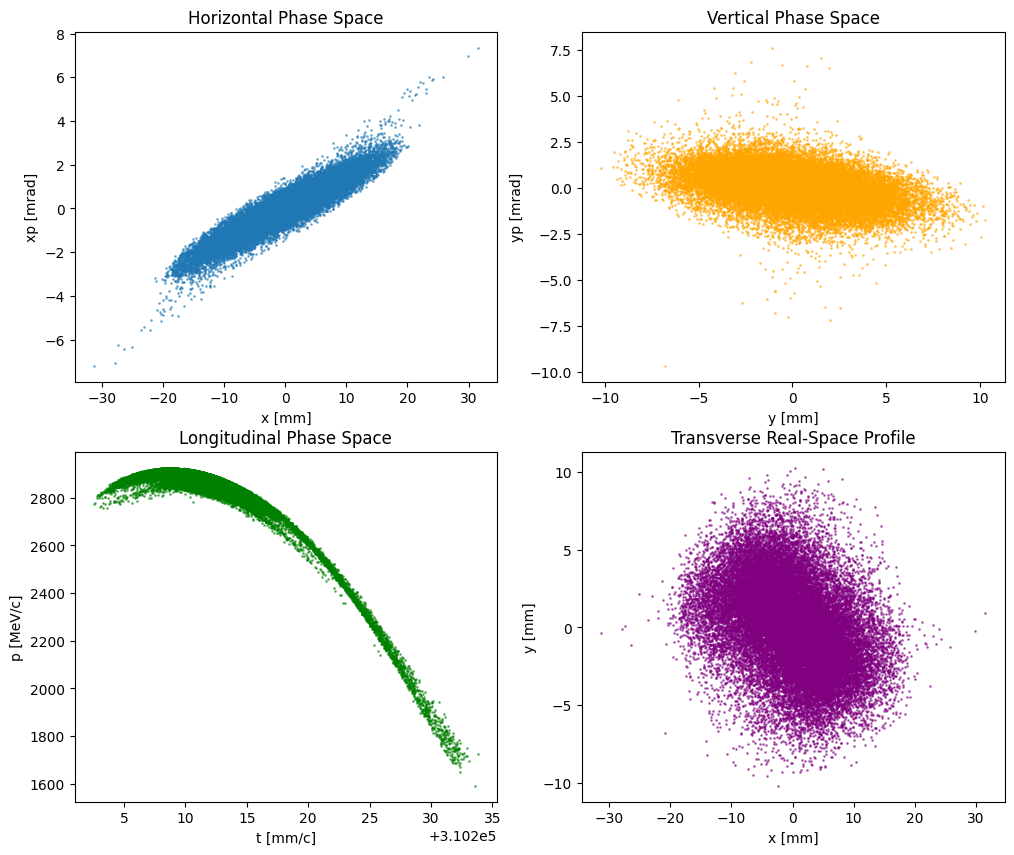

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#Horizontal Phase Space
axes[0, 0].scatter(df['x[mm]'], df['xp[mrad]'], s=1, alpha=0.5)
axes[0, 0].set_xlabel('x [mm]')
axes[0, 0].set_ylabel('xp [mrad]')
axes[0, 0].set_title('Horizontal Phase Space')

#Vertical Phase Space
axes[0, 1].scatter(df['y[mm]'], df['yp[mrad]'], s=1, alpha=0.5, color='orange')
axes[0, 1].set_xlabel('y [mm]')
axes[0, 1].set_ylabel('yp [mrad]')
axes[0, 1].set_title('Vertical Phase Space')

#Longitudinal Phase Space
main_bunch = df[df['t[mm/c]'] < 310250]
axes[1, 0].scatter(main_bunch['t[mm/c]'], main_bunch['p[MeV/c]'], s=1, alpha=0.5, color='green')
axes[1, 0].set_xlabel('t [mm/c]')
axes[1, 0].set_ylabel('p [MeV/c]')
axes[1, 0].set_title('Longitudinal Phase Space')

#Transverse Profile
axes[1, 1].scatter(df['x[mm]'], df['y[mm]'], s=1, alpha=0.5, color='purple')
axes[1, 1].set_xlabel('x [mm]')
axes[1, 1].set_ylabel('y [mm]')
axes[1, 1].set_title('Transverse Real-Space Profile')



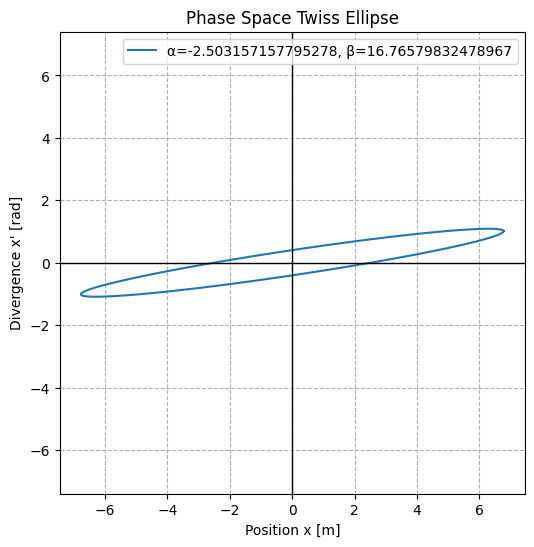

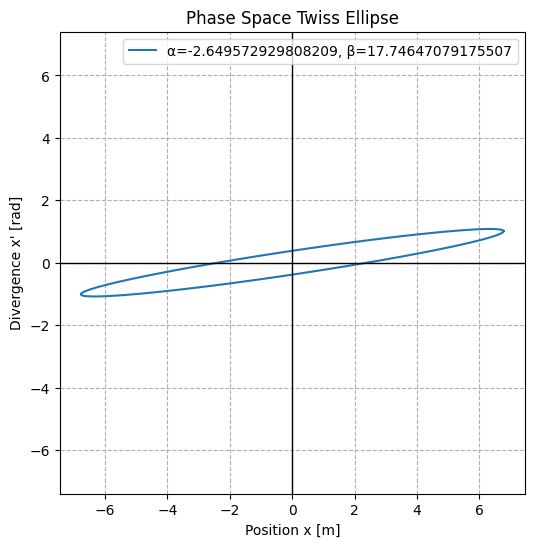

In [25]:
plot_twiss_ellipse(bx,ax,emittance_x)
plot_twiss_ellipse(by,ay,emittance_y)

In [26]:

# Save twiss results
beam_results = {
    "x": {
        "alpha": float(ax),
        "beta": float(bx),
        "gamma": float(gx),
        "dispersion": float(dx),
        "dispersion_prime": float(ddx),
        "emittance_geo": float(emittance_x)
    },
    "y": {
        "alpha": float(ay),
        "beta": float(by),
        "gamma": float(gy),
        "dispersion": float(dy),
        "dispersion_prime": float(ddy),
        "emittance_geo": float(emittance_y)
    },
    "metadata": {
        "particle_type": "positron",
        "design_energy_mev": 2860.0,
        "n_particles": len(df['ID'])
    }
}

with open('TwissResults.json', 'w') as f:
    json.dump(beam_results, f, indent=4)
